# Rang Conveyor Belt Classifier
**AIC-401 Deep Learning — Assignment 01**

This notebook trains a CNN from scratch to classify plastic objects by color:
- 🔵 Blue → Conveyor Belt A
- 🟡 Yellow → Conveyor Belt B
- 🟣 Purple → Conveyor Belt C

## Cell 1 — Install Dependencies
Run this cell only once (especially on Google Colab)

## Cell 2 — Import Libraries

In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
from warnings import filterwarnings
filterwarnings("ignore")

# Check TensorFlow version
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.21.0
GPU Available: True


## Cell 3 — Configuration
Set all hyperparameters and paths here. Change `DATASET_PATH` to your actual dataset folder.

In [18]:
# ─── PATHS ───────────────────────────────────────────────────────────────────
DATASET_PATH   = "dataset"          # Root folder containing blue/yellow/purple subfolders
MODEL_SAVE_PATH = "saved_model/conveyor_model.h5"
TFLITE_SAVE_PATH = "saved_model/conveyor_model.tflite"

# ─── IMAGE SETTINGS ──────────────────────────────────────────────────────────
IMG_SIZE    = (256, 256)            # Resize all images to 256x256
BATCH_SIZE  = 32

# ─── TRAINING SETTINGS ───────────────────────────────────────────────────────
EPOCHS      = 100
LEARNING_RATE = 0.003

# ─── CLASSES ─────────────────────────────────────────────────────────────────
CLASS_NAMES = ['blue', 'purple', 'yellow']   # alphabetical order (Keras default)
CLASS_LABELS = {
    'blue':   'Conveyor Belt A',
    'yellow': 'Conveyor Belt B',
    'purple': 'Conveyor Belt C'
}

# Create output directory
os.makedirs("saved_model", exist_ok=True)

print("Configuration set!")
print(f"Image size: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")

Configuration set!
Image size: (256, 256)
Batch size: 32
Epochs: 100


## Cell 5 — Verify Dataset Structure
Make sure your dataset folder looks like:
```
dataset/
  blue/     ← your blue object photos
  yellow/   ← your yellow object photos
  purple/   ← your purple object photos
```

In [19]:
# Verify dataset structure and count images
TRAIN_PATH = os.path.join(DATASET_PATH, 'train')
VAL_PATH   = os.path.join(DATASET_PATH, 'val')

print(f"Dataset path: {os.path.abspath(DATASET_PATH)}\n")

total_images = 0
for split_name, split_path in [('train', TRAIN_PATH), ('val', VAL_PATH)]:
    print(f"  {split_name}/")
    for class_name in sorted(os.listdir(split_path)):
        class_folder = os.path.join(split_path, class_name)
        if os.path.isdir(class_folder):
            count = len([
                f for f in os.listdir(class_folder)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))
            ])
            total_images += count
            belt = CLASS_LABELS.get(class_name, '?')
            print(f"      {class_name:<10} → {belt:<20} | {count} images")
    print()

print(f"  Total images: {total_images}")

Dataset path: /mnt/c/Users/Umar Aftab/Projects/rang/model/dataset

  train/
      blue       → Conveyor Belt A      | 83 images
      purple     → Conveyor Belt C      | 94 images
      yellow     → Conveyor Belt B      | 69 images

  val/
      blue       → Conveyor Belt A      | 22 images
      purple     → Conveyor Belt C      | 24 images
      yellow     → Conveyor Belt B      | 18 images

  Total images: 310


## Cell 6 — Preview Sample Images

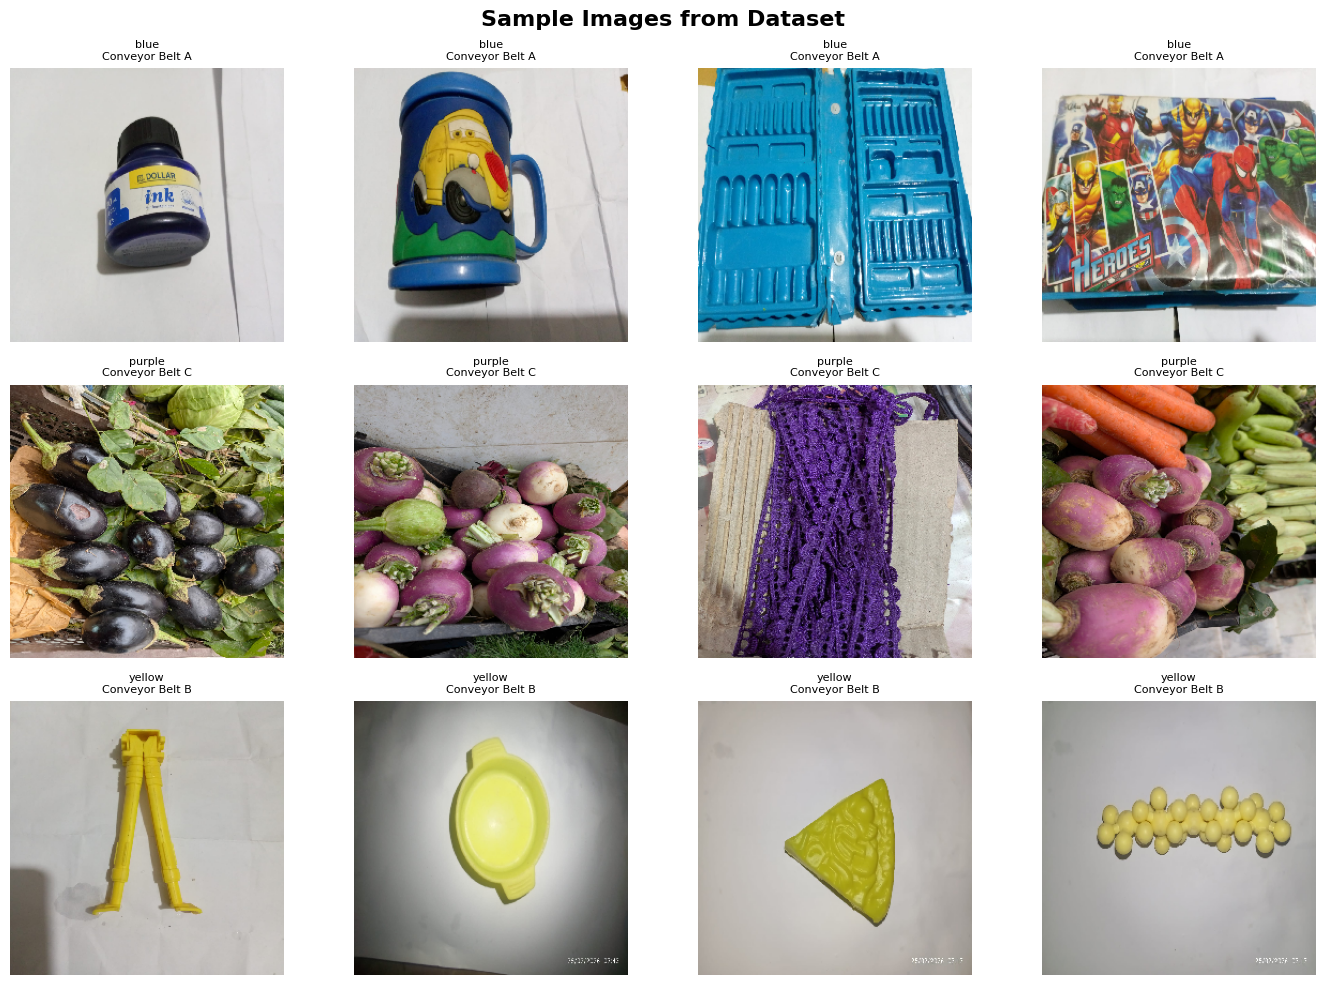

In [20]:
from tensorflow.keras.preprocessing.image import load_img

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('Sample Images from Dataset', fontsize=16, fontweight='bold')

for row, class_name in enumerate(sorted(os.listdir(TRAIN_PATH))):
    class_folder = os.path.join(TRAIN_PATH, class_name)   # ← use TRAIN_PATH
    if not os.path.isdir(class_folder):
        continue

    images = [
        f for f in os.listdir(class_folder)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ][:4]

    for col, img_name in enumerate(images):
        img = load_img(os.path.join(class_folder, img_name), target_size=IMG_SIZE)
        axes[row, col].imshow(img)
        axes[row, col].set_title(f"{class_name}\n{CLASS_LABELS.get(class_name, '')}", fontsize=8)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('saved_model/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 7 — Data Augmentation & Loading
Augmentation artificially increases dataset variety by flipping, rotating, zooming etc. This helps the model generalize better.

In [21]:
TRAIN_PATH = os.path.join(DATASET_PATH, 'train')
VAL_PATH   = os.path.join(DATASET_PATH, 'val')

# No augmentation — only normalize pixel values to [0, 1]
train_datagen = ImageDataGenerator(rescale=1.0/255)
val_datagen   = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    VAL_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

print(f"Class indices: {train_generator.class_indices}")
print(f"Training samples:   {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")

Found 246 images belonging to 3 classes.
Found 64 images belonging to 3 classes.
Class indices: {'blue': 0, 'purple': 1, 'yellow': 2}
Training samples:   246
Validation samples: 64


In [22]:
# ── Count Train & Validation Images Per Class ─────────────────────────────────

class_indices = train_generator.class_indices
idx_to_class  = {v: k for k, v in class_indices.items()}

train_counts = {}
val_counts   = {}

# Count training images per class
for idx, label in zip(train_generator.classes, train_generator.filenames):
    cls = idx_to_class[idx]
    train_counts[cls] = train_counts.get(cls, 0) + 1

# Count validation images per class
for idx, label in zip(val_generator.classes, val_generator.filenames):
    cls = idx_to_class[idx]
    val_counts[cls] = val_counts.get(cls, 0) + 1

# ── Print Summary Table ────────────────────────────────────────────────────────
print(f"{'='*55}")
print(f"  {'Class':<12} {'Train':>8} {'Validation':>12} {'Total':>8}")
print(f"{'─'*55}")

for cls in sorted(class_indices.keys()):
    tr  = train_counts.get(cls, 0)
    val = val_counts.get(cls, 0)
    tot = tr + val
    print(f"  {cls:<12} {tr:>8} {val:>12} {tot:>8}")

print(f"{'─'*55}")
total_tr  = sum(train_counts.values())
total_val = sum(val_counts.values())
total_all = total_tr + total_val
print(f"  {'TOTAL':<12} {total_tr:>8} {total_val:>12} {total_all:>8}")
print(f"{'='*55}")
print(f"\n  Split ratio — Train: {total_tr/total_all*100:.1f}%  |  Val: {total_val/total_all*100:.1f}%")

  Class           Train   Validation    Total
───────────────────────────────────────────────────────
  blue               83           22      105
  purple             94           24      118
  yellow             69           18       87
───────────────────────────────────────────────────────
  TOTAL             246           64      310

  Split ratio — Train: 79.4%  |  Val: 20.6%


## Cell 8 — Build the CNN Model
A 3-block CNN with BatchNormalization and Dropout — trained from scratch, no pretrained weights.

In [23]:
def build_model(input_shape=(128, 128, 3), num_classes=3):
    model = keras.Sequential([
        # Block 1
        layers.Conv2D(16, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D(2,2),

        # Block 2
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        # Block 3
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_model()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,939 (109.14 KB)

 Trainable params: 27,939 (109.14 KB)

 Non-trainable params: 0 (0.00 B)

## Cell 9 — Compile the Model

In [24]:
model.compile(
    # Adam optimizer: adaptive learning rate, works well for CNNs
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),

    # Categorical crossentropy: standard loss for multi-class classification
    loss='categorical_crossentropy',

    # Track accuracy during training
    metrics=['accuracy']
)

print(f"Total parameters: {model.count_params():,}")
print("Model compiled successfully!")

Total parameters: 27,939
Model compiled successfully!


## Cell 10 — Set Up Training Callbacks
Callbacks automatically improve training: save best model, reduce LR when stuck, stop early if needed.

In [25]:
callbacks = [

    # Save the best model (by validation accuracy) automatically
    keras.callbacks.ModelCheckpoint(
        filepath=MODEL_SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    # Reduce learning rate by 50% if val_accuracy doesn't improve for 5 epochs
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),

    # Stop training early if val_accuracy doesn't improve for 10 epochs
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
]

print("Callbacks configured:")
print("  ✓ ModelCheckpoint — saves best model")
print("  ✓ ReduceLROnPlateau — lowers LR when stuck")
print("  ✓ EarlyStopping — stops if no improvement")

Callbacks configured:
  ✓ ModelCheckpoint — saves best model
  ✓ ReduceLROnPlateau — lowers LR when stuck
  ✓ EarlyStopping — stops if no improvement


## Cell 11 — Train the Model 🚀

In [26]:
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 694ms/step - accuracy: 0.2514 - loss: 1.1286
Epoch 1: val_accuracy improved from None to 0.40625, saving model to saved_model/conveyor_model.h5



Epoch 1: finished saving model to saved_model/conveyor_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.3049 - loss: 1.1093 - val_accuracy: 0.4062 - val_loss: 1.0839 - learning_rate: 0.0030
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 523ms/step - accuracy: 0.4737 - loss: 1.0576
Epoch 2: val_accuracy improved from 0.40625 to 0.64062, saving model to saved_model/conveyor_model.h5



Epoch 2: finished saving model to saved_model/conveyor_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 721ms/step - accuracy: 0.4756 - loss: 1.0355 - val_accuracy: 0.6406 - val_loss: 0.9798 - learning_rate: 0.0030
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.5992 - loss: 0.8772
Epoch 3: val_accuracy did not improve from 0.64062
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 370ms/step - accuracy: 0.6138 - loss: 0.8423 - val_accuracy: 0.5938 - val_loss: 0.8647 - learning_rate: 0.0030
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.6469 - loss: 0.7102
Epoch 4: val_accuracy did not improve from 0.64062
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 730ms/step - accuracy: 0.6341 - loss: 0.7085 - val_accuracy: 0.5625 - val_loss: 0.8092 - learning_rate: 0.0030
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 577ms/step - accuracy: 0.6724 - loss: 0.6560
Epoch 5: val_accuracy did not improve from 0.64062
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 794ms/step - accuracy: 0.6463 - loss: 0.6919 - val_accuracy: 0.5469 - val_loss: 0.


Epoch 6: finished saving model to saved_model/conveyor_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 802ms/step - accuracy: 0.7398 - loss: 0.5928 - val_accuracy: 0.7188 - val_loss: 0.6556 - learning_rate: 0.0030
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - accuracy: 0.8016 - loss: 0.4790
Epoch 7: val_accuracy did not improve from 0.71875
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 752ms/step - accuracy: 0.7724 - loss: 0.4749 - val_accuracy: 0.6875 - val_loss: 0.5800 - learning_rate: 0.0030
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - accuracy: 0.7782 - loss: 0.4266
Epoch 8: val_accuracy did not improve from 0.71875
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 757ms/step - accuracy: 0.7724 - loss: 0.4246 - val_accuracy: 0.6875 - val_loss: 0.6003 - learning_rate: 0.0030
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.8081 - loss: 0.4080
Epoch 9: val_accuracy did not improve from 0.71875
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 364ms/step - accuracy: 0.8293 - loss: 0.3911 - val_accuracy: 0.7188 - val_loss: 0.


Epoch 12: finished saving model to saved_model/conveyor_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 736ms/step - accuracy: 0.8659 - loss: 0.3549 - val_accuracy: 0.7344 - val_loss: 0.5033 - learning_rate: 0.0015
Epoch 13/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.8244 - loss: 0.3597
Epoch 13: val_accuracy improved from 0.73438 to 0.79688, saving model to saved_model/conveyor_model.h5



Epoch 13: finished saving model to saved_model/conveyor_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 745ms/step - accuracy: 0.8496 - loss: 0.3242 - val_accuracy: 0.7969 - val_loss: 0.4187 - learning_rate: 0.0015
Epoch 14/100
6/8 ━━━━━━━━━━━━━━━━━━━━ 1s 558ms/step - accuracy: 0.8227 - loss: 0.4066
Epoch 14: val_accuracy did not improve from 0.79688
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 417ms/step - accuracy: 0.8496 - loss: 0.3149 - val_accuracy: 0.7656 - val_loss: 0.4103 - learning_rate: 0.0015
Epoch 15/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.8761 - loss: 0.3359
Epoch 15: val_accuracy did not improve from 0.79688
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 699ms/step - accuracy: 0.8740 - loss: 0.3170 - val_accuracy: 0.7656 - val_loss: 0.4177 - learning_rate: 0.0015
Epoch 16/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 626ms/step - accuracy: 0.8726 - loss: 0.3501
Epoch 16: val_accuracy did not improve from 0.79688
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 878ms/step - accuracy: 0.8659 - loss: 0.3069 - val_accuracy: 0.7812 - val_l


Epoch 18: finished saving model to saved_model/conveyor_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 741ms/step - accuracy: 0.9024 - loss: 0.2297 - val_accuracy: 0.8906 - val_loss: 0.3859 - learning_rate: 0.0015
Epoch 19/100
6/8 ━━━━━━━━━━━━━━━━━━━━ 1s 734ms/step - accuracy: 0.8626 - loss: 0.3102
Epoch 19: val_accuracy did not improve from 0.89062
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 543ms/step - accuracy: 0.8740 - loss: 0.2959 - val_accuracy: 0.8281 - val_loss: 0.3697 - learning_rate: 0.0015
Epoch 20/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.8869 - loss: 0.2474
Epoch 20: val_accuracy did not improve from 0.89062
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 808ms/step - accuracy: 0.8984 - loss: 0.2550 - val_accuracy: 0.8125 - val_loss: 0.4048 - learning_rate: 0.0015
Epoch 21/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 523ms/step - accuracy: 0.8955 - loss: 0.2408
Epoch 21: val_accuracy did not improve from 0.89062
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 725ms/step - accuracy: 0.8943 - loss: 0.2555 - val_accuracy: 0.8438 - val_l

## Cell 12 — Plot Training Curves
Visualize accuracy and loss over epochs. Take a screenshot of this for your assignment report.

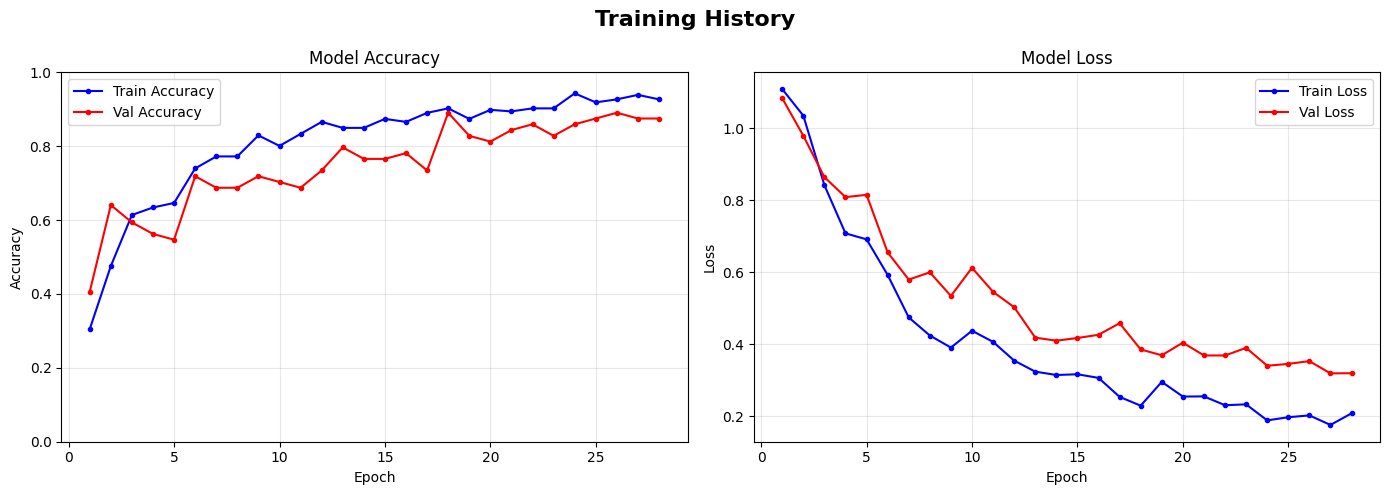

Training curves saved to saved_model/training_curves.png


In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=16, fontweight='bold')

epochs_ran = range(1, len(history.history['accuracy']) + 1)

# ── Accuracy Plot ─────────────────────────────────────────────────────────────
ax1.plot(epochs_ran, history.history['accuracy'],     'b-o', label='Train Accuracy', markersize=3)
ax1.plot(epochs_ran, history.history['val_accuracy'], 'r-o', label='Val Accuracy',   markersize=3)
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1])

# ── Loss Plot ─────────────────────────────────────────────────────────────────
ax2.plot(epochs_ran, history.history['loss'],     'b-o', label='Train Loss', markersize=3)
ax2.plot(epochs_ran, history.history['val_loss'], 'r-o', label='Val Loss',   markersize=3)
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('saved_model/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved to saved_model/training_curves.png")

## Cell 13 — Evaluate on Validation Set
Get final accuracy and detailed per-class metrics.

In [28]:
# Load the best saved model
best_model = keras.models.load_model(MODEL_SAVE_PATH)

# Evaluate on validation set
val_loss, val_accuracy = best_model.evaluate(val_generator, verbose=0)
print(f"{'='*40}")
print(f"  Validation Loss:     {val_loss:.4f}")
print(f"  Validation Accuracy: {val_accuracy*100:.2f}%")
print(f"{'='*40}")

# Get per-class predictions
val_generator.reset()
predictions = best_model.predict(val_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_generator.classes
class_names = list(val_generator.class_indices.keys())

# Detailed classification report
print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_names))

# Save class indices from training generator for later use
best_model_class_indices = train_generator.class_indices
print("Class indices saved:", best_model_class_indices)

  Validation Loss:     0.3859
  Validation Accuracy: 89.06%
2/2 ━━━━━━━━━━━━━━━━━━━━ -1s 150ms/step   

Classification Report:
              precision    recall  f1-score   support

        blue       0.94      0.73      0.82        22
      purple       0.82      0.96      0.88        24
      yellow       0.95      1.00      0.97        18

    accuracy                           0.89        64
   macro avg       0.90      0.90      0.89        64
weighted avg       0.90      0.89      0.89        64

Class indices saved: {'blue': 0, 'purple': 1, 'yellow': 2}


## Cell 14 — Confusion Matrix
Shows exactly which classes are being confused. Take a screenshot for your report.

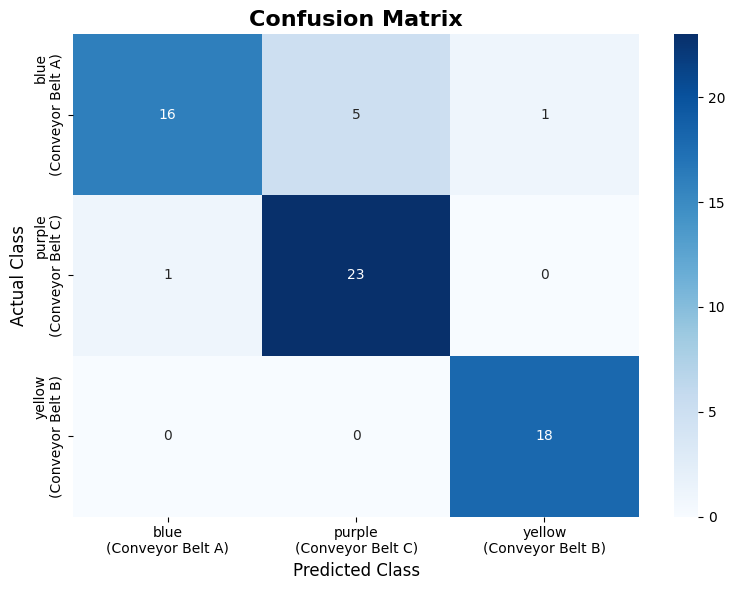

Confusion matrix saved to saved_model/confusion_matrix.png


In [29]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[f"{c}\n({CLASS_LABELS.get(c,'')})" for c in class_names],
    yticklabels=[f"{c}\n({CLASS_LABELS.get(c,'')})" for c in class_names]
)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.tight_layout()
plt.savefig('saved_model/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved to saved_model/confusion_matrix.png")

## Cell 15 — Test on a Single Image
Simulate what happens when the evaluator shows a new object.

Found 18 test images



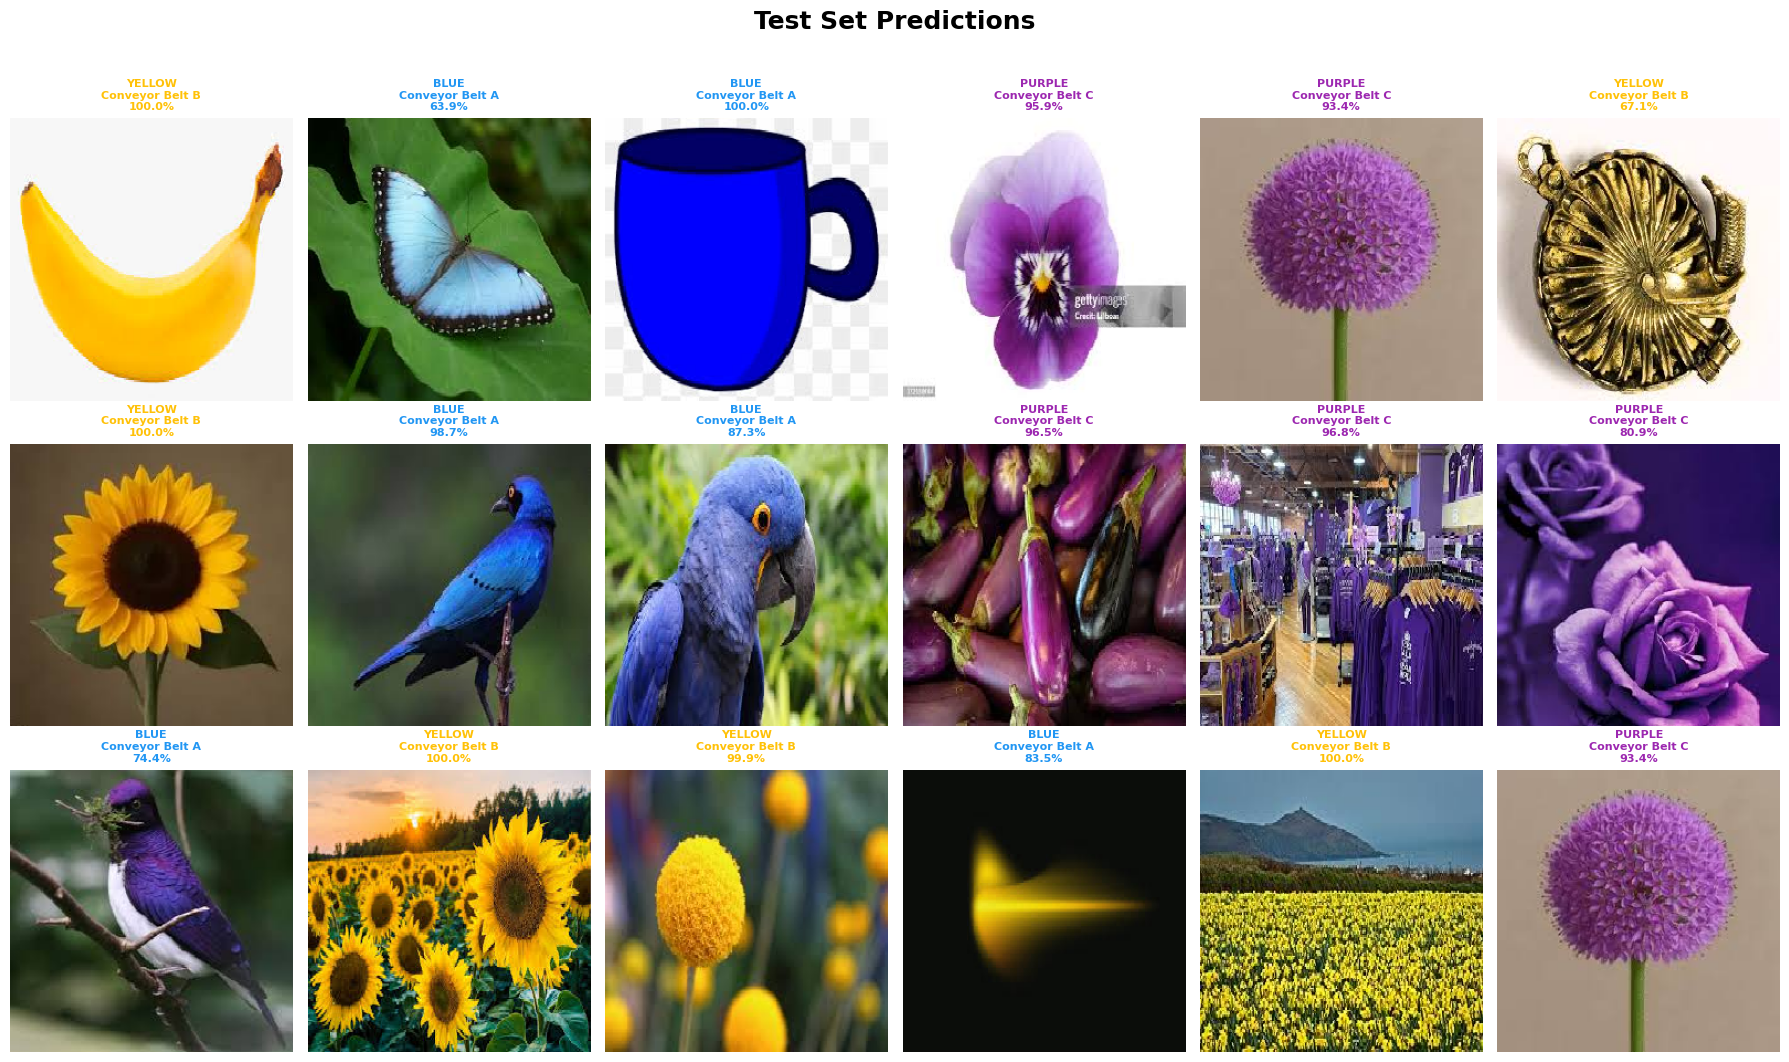


  TEST RESULTS SUMMARY
  download (1).jpeg         → yellow   | Conveyor Belt B (100.0%)
  download (2).jpeg         → blue     | Conveyor Belt A (63.9%)
  download (3).jpeg         → blue     | Conveyor Belt A (100.0%)
  download.jpeg             → purple   | Conveyor Belt C (95.9%)
  images (1).jpg            → purple   | Conveyor Belt C (93.4%)
  images (10).jpg           → yellow   | Conveyor Belt B (67.1%)
  images (11).jpg           → yellow   | Conveyor Belt B (100.0%)
  images (12).jpg           → blue     | Conveyor Belt A (98.7%)
  images (13).jpg           → blue     | Conveyor Belt A (87.3%)
  images (2).jpg            → purple   | Conveyor Belt C (96.5%)
  images (3).jpg            → purple   | Conveyor Belt C (96.8%)
  images (4).jpg            → purple   | Conveyor Belt C (80.9%)
  images (5).jpg            → blue     | Conveyor Belt A (74.4%)
  images (6).jpg            → yellow   | Conveyor Belt B (100.0%)
  images (7).jpg            → yellow   | Conveyor Belt B (99.9

In [30]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

TEST_PATH = "dataset/test"   # folder with your 18 test images

# Get all images from test folder
test_images = sorted([
    f for f in os.listdir(TEST_PATH)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
])

print(f"Found {len(test_images)} test images\n")

# Reverse class indices: {0: 'blue', 1: 'purple', 2: 'yellow'}
idx_to_class = {v: k for k, v in best_model_class_indices.items()}

# ── Run predictions ───────────────────────────────────────────────────────────
results = []
for img_name in test_images:
    img_path  = os.path.join(TEST_PATH, img_name)
    img       = load_img(img_path, target_size=IMG_SIZE)
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds         = best_model.predict(img_array, verbose=0)[0]
    predicted_idx = np.argmax(preds)
    predicted_cls = idx_to_class[predicted_idx]
    confidence    = preds[predicted_idx] * 100
    belt          = CLASS_LABELS[predicted_cls]

    results.append({
        'img':       img,
        'name':      img_name,
        'class':     predicted_cls,
        'belt':      belt,
        'confidence': confidence
    })

# ── Display all predictions in a single grid ──────────────────────────────────
cols = 6
rows = (len(results) + cols - 1) // cols   # auto calculate rows

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.5))
fig.suptitle('Test Set Predictions', fontsize=18, fontweight='bold', y=1.02)
axes = axes.flatten()

# Color coding for belt labels
BELT_COLORS = {
    'Conveyor Belt A': '#2196F3',   # blue
    'Conveyor Belt B': '#FFC107',   # yellow
    'Conveyor Belt C': '#9C27B0',   # purple
}

for i, r in enumerate(results):
    axes[i].imshow(r['img'])
    axes[i].axis('off')

    belt_color = BELT_COLORS.get(r['belt'], 'gray')
    axes[i].set_title(
        f"{r['class'].upper()}\n{r['belt']}\n{r['confidence']:.1f}%",
        fontsize=8,
        fontweight='bold',
        color=belt_color
    )

# Hide any unused subplots
for j in range(len(results), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('saved_model/test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print summary ─────────────────────────────────────────────────────────────
print(f"\n{'='*45}")
print(f"  TEST RESULTS SUMMARY")
print(f"{'='*45}")
for r in results:
    print(f"  {r['name']:<25} → {r['class']:<8} | {r['belt']} ({r['confidence']:.1f}%)")

print(f"{'='*45}")
print(f"  Saved → saved_model/test_predictions.png")

## Cell 16 — Export to TFLite (for Flutter App)
Converts the Keras model to a lightweight format that runs on Android.

In [31]:
print("Converting model to TFLite format...")

# Load best model
best_model = keras.models.load_model(MODEL_SAVE_PATH)

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)

# Optional: Optimize for mobile (reduces size, minimal accuracy loss)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

# Save the TFLite model
with open(TFLITE_SAVE_PATH, 'wb') as f:
    f.write(tflite_model)

# Report file sizes
h5_size     = os.path.getsize(MODEL_SAVE_PATH) / 1024
tflite_size = os.path.getsize(TFLITE_SAVE_PATH) / 1024

print(f"\n✅ TFLite model saved to: {TFLITE_SAVE_PATH}")
print(f"   Keras model size:  {h5_size:.1f} KB")
print(f"   TFLite model size: {tflite_size:.1f} KB")
print(f"   Size reduction:    {(1 - tflite_size/h5_size)*100:.1f}%")
print(f"\n➡️  Copy this file to: app/assets/conveyor_model.tflite")

Converting model to TFLite format...


INFO:tensorflow:Assets written to: /tmp/tmp8atp0nyk/assets


INFO:tensorflow:Assets written to: /tmp/tmp8atp0nyk/assets


Saved artifact at '/tmp/tmp8atp0nyk'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  124837603995920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124837603999184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124837603998032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124837603997648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124837576265168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124837576261904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124837576265552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124837576263632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124837576266896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124837576266128: TensorSpec(shape=(), dtype=tf.resource, name=None)

✅ TFLite model

## Cell 17 — Summary of All Saved Files

In [32]:
print("="*50)
print("  RANG CLASSIFIER — TRAINING COMPLETE")
print("="*50)
print(f"\n  Final Validation Accuracy: {val_accuracy*100:.2f}%")
print(f"  Final Validation Loss:     {val_loss:.4f}")
print(f"\n  Saved Files:")

for fname in os.listdir('saved_model'):
    fpath = os.path.join('saved_model', fname)
    size = os.path.getsize(fpath) / 1024
    print(f"    📄 {fname:35s} {size:8.1f} KB")

print(f"\n  Class Mapping:")
for class_name, idx in sorted(train_generator.class_indices.items(), key=lambda x: x[1]):
    print(f"    Index {idx} → {class_name:10s} → {CLASS_LABELS.get(class_name, '?')}")

print("\n  Next step: Copy conveyor_model.tflite to app/assets/")
print("="*50)

  RANG CLASSIFIER — TRAINING COMPLETE

  Final Validation Accuracy: 89.06%
  Final Validation Loss:     0.3859

  Saved Files:
    📄 confusion_matrix.png                    54.9 KB
    📄 conveyor_model.h5                      378.0 KB
    📄 conveyor_model.tflite                   36.1 KB
    📄 sample_images.png                     2584.5 KB
    📄 test_predictions.png                  3159.9 KB
    📄 training_curves.png                     98.4 KB

  Class Mapping:
    Index 0 → blue       → Conveyor Belt A
    Index 1 → purple     → Conveyor Belt C
    Index 2 → yellow     → Conveyor Belt B

  Next step: Copy conveyor_model.tflite to app/assets/
